In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("data/titanic.csv")

In [3]:
df.head()

""" 
Survived: 0=dead, 1=alive
Pclass: 1=first class, 2=second class, 3=thrid class
SibSp: Number of siblings
Parch: Number of parents/children that share the fare
Fare: ticket price
Cabin: Cabin number
Embarked: C=Cherbourg, Q=Queenstown, S=Southampton
"""

' \nSurvived: 0=dead, 1=alive\nPclass: 1=first class, 2=second class, 3=thrid class\nSibSp: Number of siblings\nParch: Number of parents/children that share the fare\nFare: ticket price\nCabin: Cabin number\nEmbarked: C=Cherbourg, Q=Queenstown, S=Southampton\n'

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Créer un DataFrame avec les variables numériques + encodage one-hot
df_corr = df.select_dtypes(include=[np.number]).copy()
df_corr["Sex_male"] = (df["Sex"] == "male").astype(int)
df_corr = pd.concat([df_corr, pd.get_dummies(df["Embarked"], prefix="Embarked")], axis=1)

# Supprimer les colonnes non pertinentes
df_corr = df_corr.drop(["PassengerId", "Name", "Fare", "Cabin", "Ticket"], axis=1, errors='ignore')

df_corr.head()

,Survived,Pclass,Age,SibSp,Parch,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,1,False,False,True
1,1,1,38.0,1,0,0,True,False,False
2,1,3,26.0,0,0,0,False,False,True
3,1,1,35.0,1,0,0,False,False,True
4,0,3,35.0,0,0,1,False,False,True


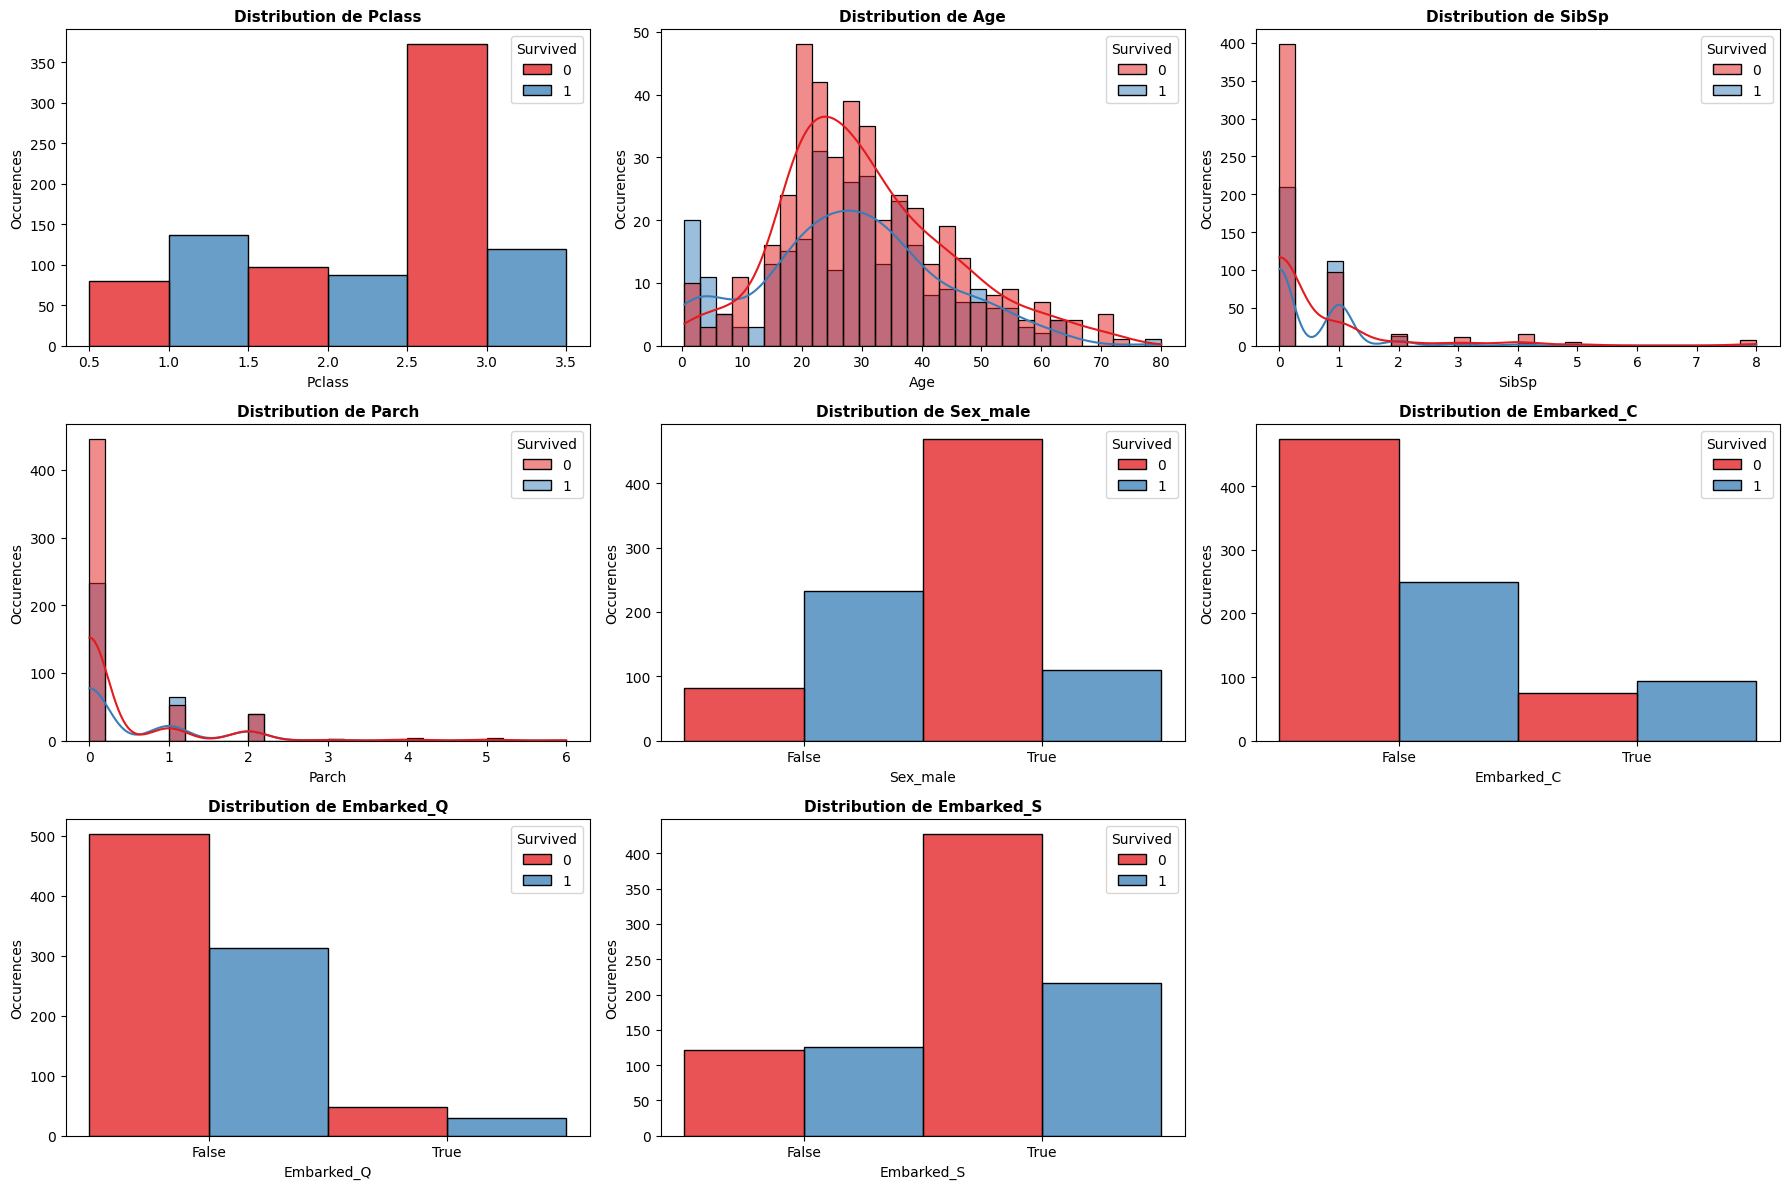

In [6]:
NB_COLS = 3
selected_cols = df_corr.drop(["Survived"], axis=1).columns
nb_rows = int(np.ceil(len(selected_cols) / NB_COLS))

plt.figure(figsize=(18, nb_rows * 4))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(nb_rows, NB_COLS, i)
    
    # Pour les variables numériques continues, utiliser kde
    if df_corr[col].dtype in ['float64', 'int64'] and col not in ['Survived', 'Pclass', 'Sex_male'] and not col.startswith('Embarked_'):
        sns.histplot(data=df_corr, x=col, hue="Survived", bins=30, kde=True, palette='Set1')
    else:
        # Pour les variables catégorielles ou discrètes
        sns.histplot(data=df_corr, x=col, hue="Survived", discrete=True, multiple='dodge', palette='Set1')
        
        # Si c'est une colonne binaire (0/1), afficher True/False
        if df_corr[col].nunique() == 2 and set(df_corr[col].unique()).issubset({0, 1, True, False}):
            plt.xticks([0, 1], ['False', 'True'])
    
    plt.title(f'Distribution de {col}', fontsize=11, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Occurences')

plt.tight_layout()
plt.show()

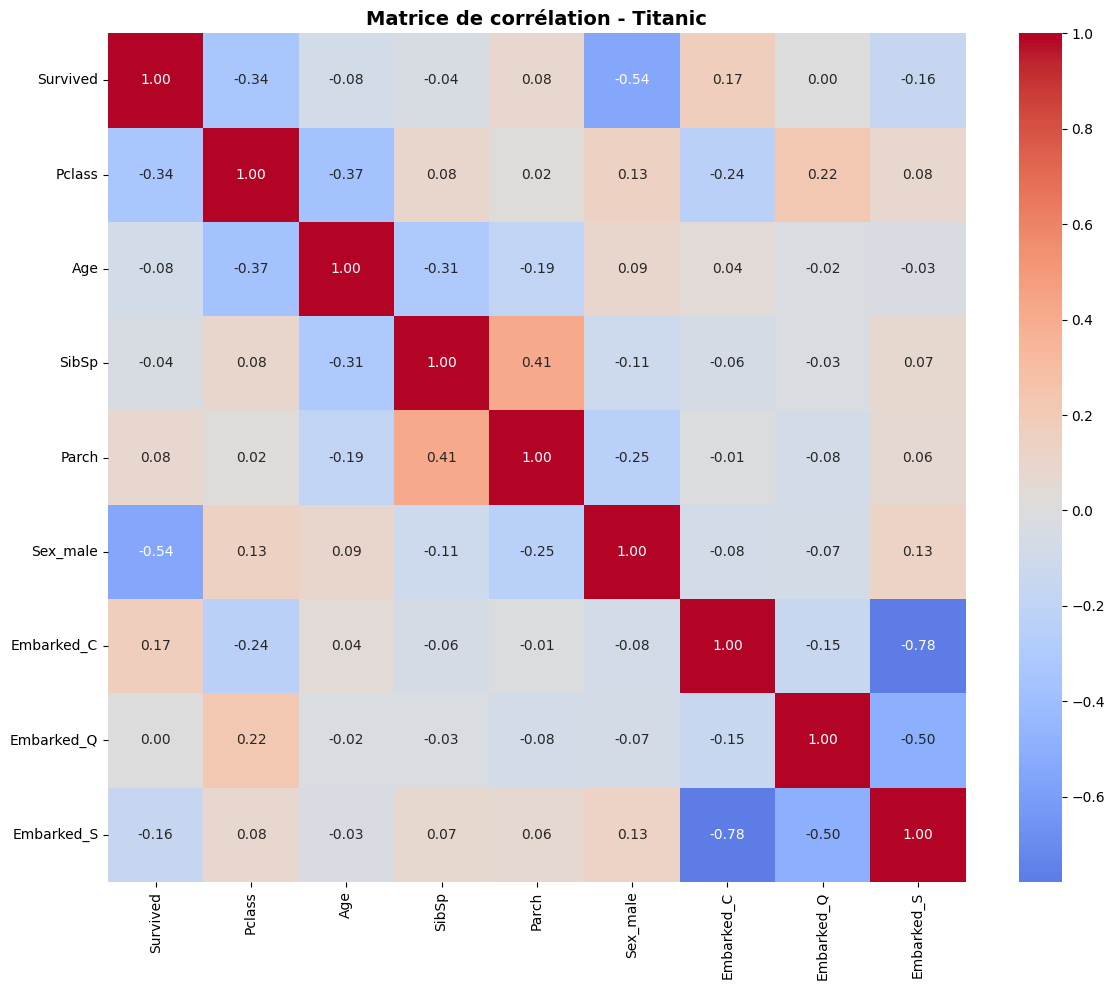

: 

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt='.2f', center=0)
plt.title("Matrice de corrélation - Titanic", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()